TASK 6: VISUALIZATIONS SUMMARY

CHARTS CREATED:
1. Box Plot - Monthly Charges by Churn:
   -  Churned customers paid $13 more on the average section.
   -  Even the cheapest churned customers paid more than most loyal customers overall.

2. Violin Plot - Tenure by Churn:
   - Half of the churned customers left within 10 months.
   - Loyal customers spread across all tenures.

3. Correlation Chart - All Features vs Churn:
   - Fiber optic internet is the first strongest churn driver.
   - Electronic check is the second strongest churn driver.
   - Long tenure = strongest churn preventer.
   - Two year contract is the second strongest preventer.

4. Pair Plot - Key Variables Relationships:
   - New high paying customers cluster together.
   - Long term customers have high total charges, but low churn.
   - Clear separation between the churned and stayed customers across all variables.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Cleaned_Churn_Data.csv')

sns.set_style("whitegrid")
sns.set_palette("husl")

print("Shape:", df.shape)

Shape: (7043, 25)


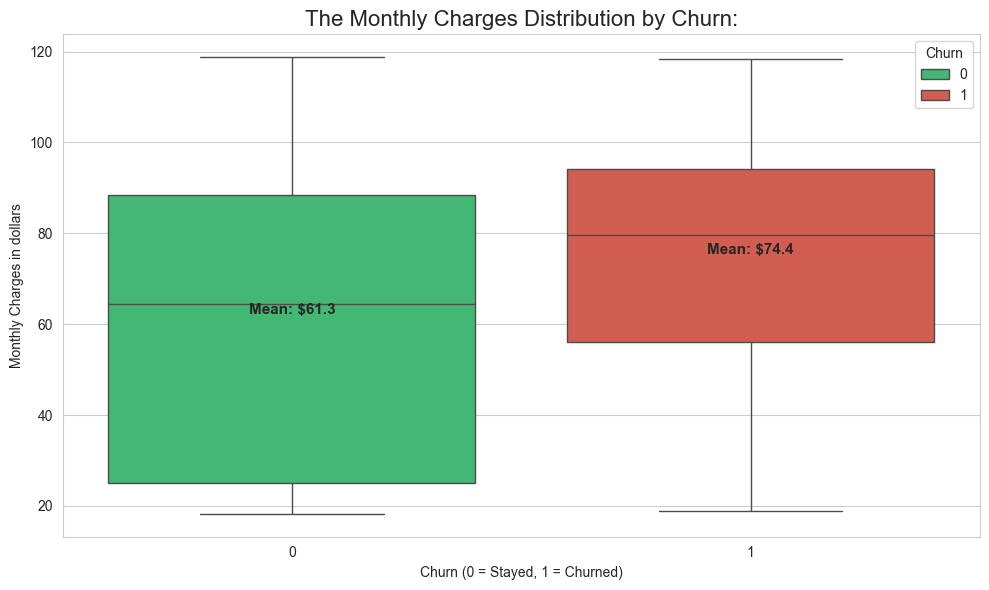

The Monthly Charges Statistics by Churn:
        count   mean    std    min    25%    50%   75%     max
Churn                                                         
0      5174.0  61.27  31.09  18.25  25.10  64.43  88.4  118.75
1      1869.0  74.44  24.67  18.85  56.15  79.65  94.2  118.35


In [2]:
plt.figure(figsize = (10, 6))
sns.boxplot(data = df, x = 'Churn', y = 'MonthlyCharges', hue = 'Churn', 
            palette = ['#2ecc71', 
                       '#e74c3c'])

plt.title('The Monthly Charges Distribution by Churn:', fontsize = 16)
plt.xlabel('Churn (0 = Stayed, 1 = Churned)')
plt.ylabel('Monthly Charges in dollars')

for i, group in enumerate([0, 1]):
    mean_val = df[df['Churn'] == group]['MonthlyCharges'].mean()
    plt.text(i, mean_val + 1, f'Mean: ${mean_val:.1f}', ha = 'center',
             fontsize = 11, fontweight = 'bold')

plt.tight_layout()
plt.show()

print("The Monthly Charges Statistics by Churn:")
print(df.groupby('Churn')['MonthlyCharges'].describe().round(2))

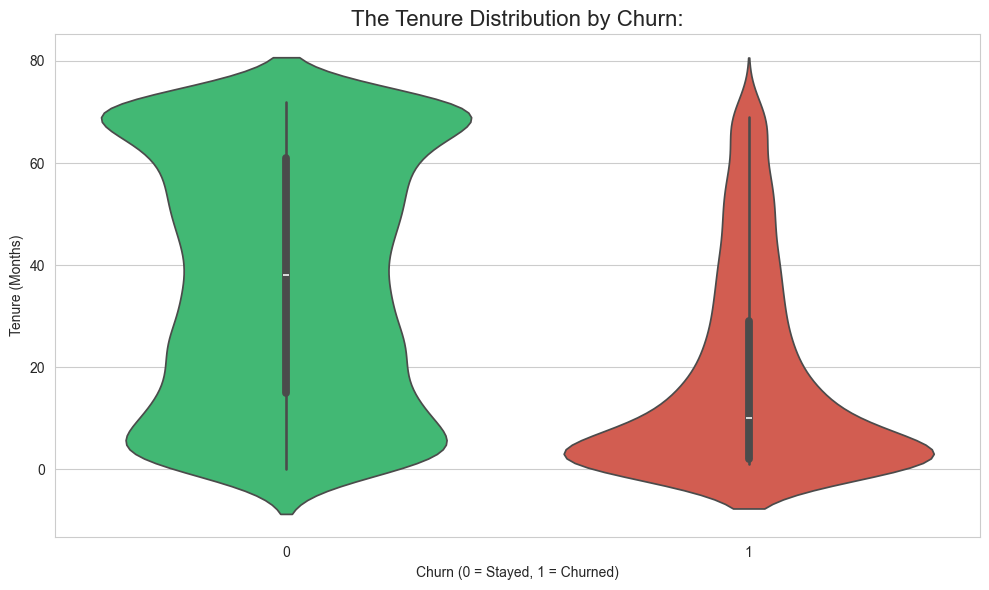

The Tenure Statistics by Churn:
        count   mean    std  min   25%   50%   75%   max
Churn                                                   
0      5174.0  37.57  24.11  0.0  15.0  38.0  61.0  72.0
1      1869.0  17.98  19.53  1.0   2.0  10.0  29.0  72.0


In [3]:
plt.figure(figsize = (10, 6))
sns.violinplot(data = df, x = 'Churn', y = 'tenure', hue='Churn',
               palette = ['#2ecc71', '#e74c3c'], legend = False)

plt.title('The Tenure Distribution by Churn:', fontsize = 16)
plt.xlabel('Churn (0 = Stayed, 1 = Churned)')
plt.ylabel('Tenure (Months)')

plt.tight_layout()
plt.show()

print("The Tenure Statistics by Churn:")
print(df.groupby('Churn')['tenure'].describe().round(2))

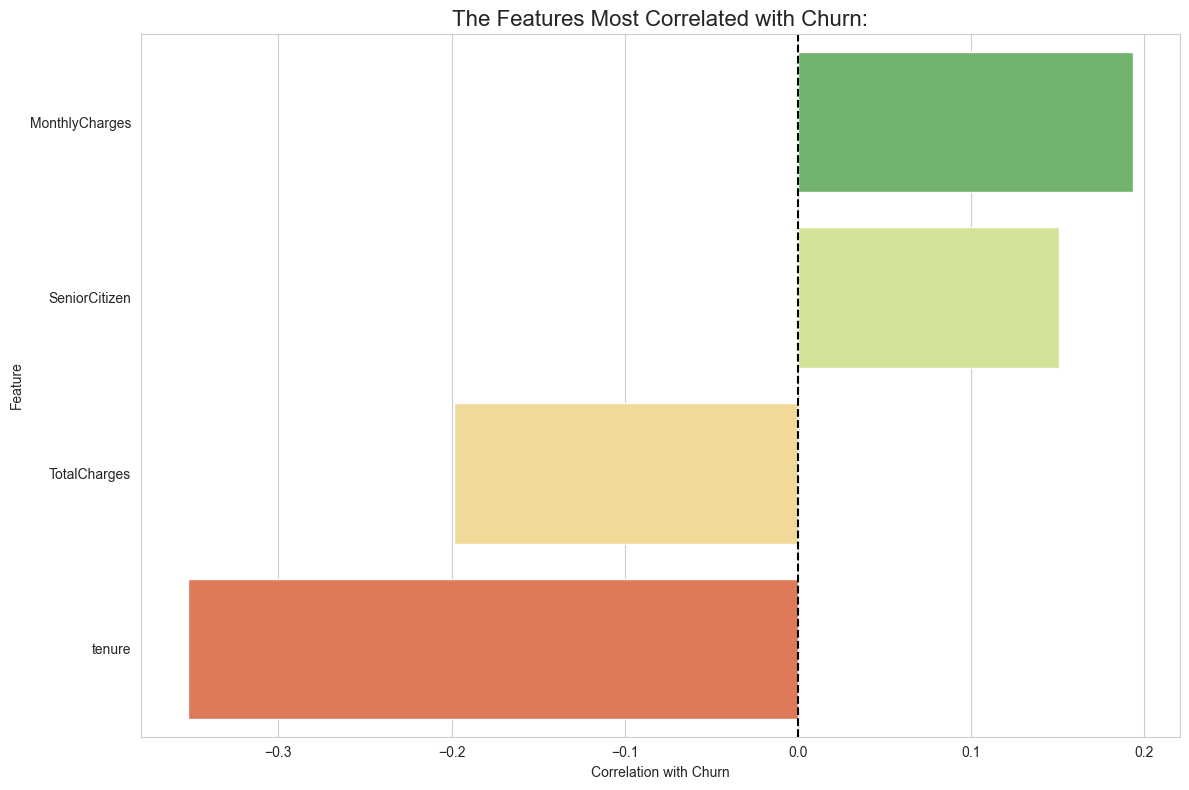

The Top factors that correlated with Churn:
MonthlyCharges    0.193
SeniorCitizen     0.151
TotalCharges     -0.198
tenure           -0.352
Name: Churn, dtype: float64


In [6]:
plt.figure(figsize = (12, 8))

df_corr = df.select_dtypes(include = ['number'])

correlations = df_corr.corr()['Churn'].sort_values(ascending = False)

correlations = correlations.drop('Churn')

top_correlations = pd.concat([correlations.head(8), correlations.tail(5)])

sns.barplot(x = top_correlations.values, y = top_correlations.index,
            hue = top_correlations.index, palette = 'RdYlGn_r', legend = False)

plt.title('The Features Most Correlated with Churn:', fontsize = 16)
plt.xlabel('Correlation with Churn')
plt.ylabel('Feature')
plt.axvline(x = 0, color = 'black', linestyle = '--')
plt.tight_layout()
plt.savefig('correlation_chart.png', bbox_inches = 'tight', dpi = 150)
plt.show()

print("The Top factors that correlated with Churn:")
print(correlations.round(3))

In [6]:
print(df.dtypes)
print("These are the full columns")

customerID                                   str
SeniorCitizen                              int64
tenure                                     int64
MultipleLines                                str
OnlineSecurity                               str
OnlineBackup                                 str
DeviceProtection                             str
TechSupport                                  str
StreamingTV                                  str
StreamingMovies                              str
MonthlyCharges                           float64
TotalCharges                             float64
Churn                                      int64
Contract_One year                           bool
Contract_Two year                           bool
PaymentMethod_Credit card (automatic)       bool
PaymentMethod_Electronic check              bool
PaymentMethod_Mailed check                  bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
gender_Male         

In [9]:
df_numeric = df.copy()

df_numeric = df_numeric.drop(columns = ['customerID'])

bool_cols = df_numeric.select_dtypes(include = ['bool']).columns
df_numeric[bool_cols] = df_numeric[bool_cols].astype(int)

str_cols = df_numeric.select_dtypes(include = ['object']).columns
print("The text columns being encoded:", str_cols.tolist())
df_numeric = pd.get_dummies(df_numeric, columns = str_cols, drop_first = True)

correlations = df_numeric.corr()['Churn'].sort_values(ascending = False)
correlations = correlations.drop('Churn')

print("\nAll correlations with Churn:")
print(correlations.round(3))

The text columns being encoded: ['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

All correlations with Churn:
InternetService_Fiber optic              0.308
PaymentMethod_Electronic check           0.302
MonthlyCharges                           0.193
PaperlessBilling_Yes                     0.192
SeniorCitizen                            0.151
StreamingTV_Yes                          0.063
StreamingMovies_Yes                      0.061
MultipleLines_Yes                        0.040
PhoneService_Yes                         0.012
gender_Male                             -0.009
MultipleLines_No phone service          -0.012
DeviceProtection_Yes                    -0.066
OnlineBackup_Yes                        -0.082
PaymentMethod_Mailed check              -0.092
PaymentMethod_Credit card (automatic)   -0.134
Partner_Yes                             -0.150
Dependents_Yes                          -0.164
TechSupport_Yes   

C:\Users\thend\AppData\Local\Temp\ipykernel_16592\3263328936.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = df_numeric.select_dtypes(include = ['object']).columns


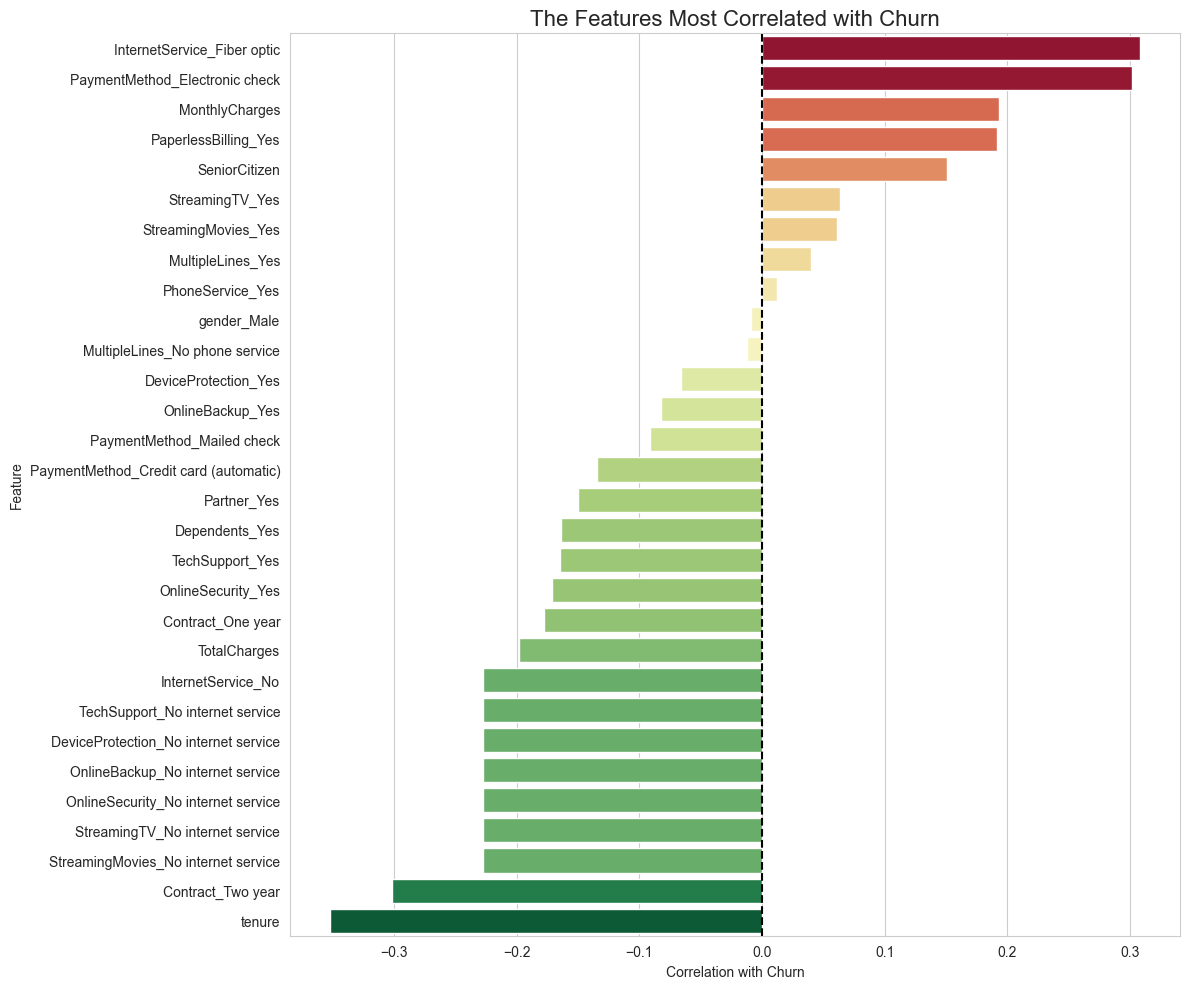

In [10]:
plt.figure(figsize = (12, 10))

sns.barplot(x = correlations.values, y = correlations.index,
            hue = correlations.values,
            palette = 'RdYlGn_r',
            legend = False)

plt.title('The Features Most Correlated with Churn', fontsize=16)
plt.xlabel('Correlation with Churn')
plt.ylabel('Feature')
plt.axvline(x = 0, color = 'black', linestyle = '--', linewidth = 1.5)
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

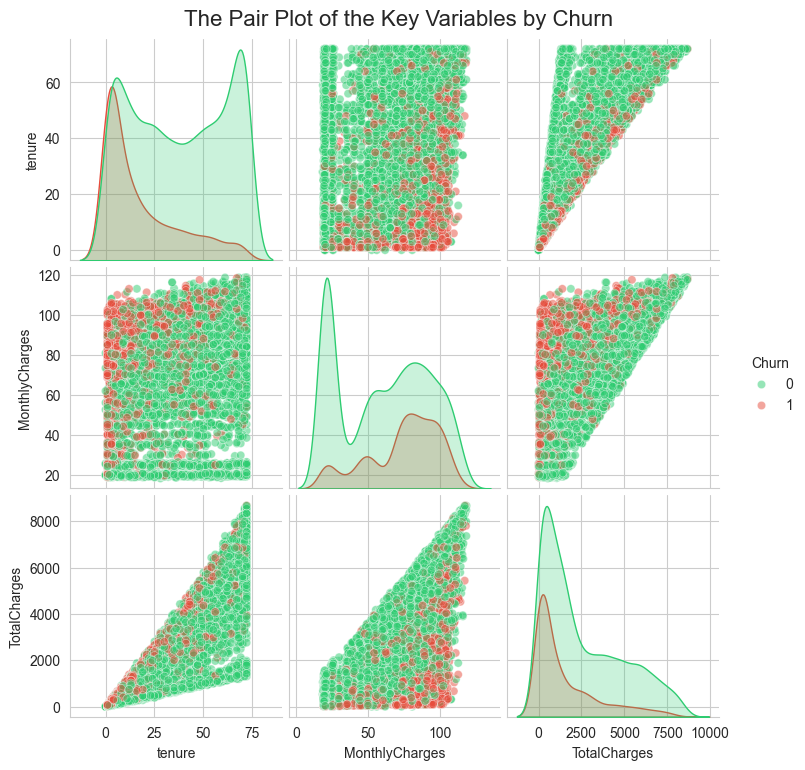

In [11]:
key_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']

plt.figure()
pair_plot = sns.pairplot(df[key_cols], hue = 'Churn', 
                         palette = ['#2ecc71', '#e74c3c'],
                          plot_kws = {'alpha': 0.5},
                          diag_kind = 'kde')

pair_plot.fig.suptitle('The Pair Plot of the Key Variables by Churn', 
                        fontsize = 16, y = 1.02)
plt.show()